# Build a probe configuration file from scratch

Desk work, run locally. A probe file is plain JSON, so nothing here needs a GPU,
Kilosort, torch or the HPC.

This notebook does the one thing no script does: **define a geometry by hand**. If
you already have a map in some other format -- a SpikeGLX `.meta`, a Blackrock
`.cmp`, an old Kilosort `.mat` -- that is a conversion, and `tools/make_probe.py`
is the script for it. See the last section.

> **No code can tell you a channel map is correct.** Validation catches structural
> mistakes: duplicate channels, overlapping contacts, a wrong `n_chan`. Whether the
> map matches how the array is actually wired is something only the plot and the
> array's documentation can tell you. Look at the picture.

In [1]:
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

from spikesorting._plots import plot_probe_channel_order, plot_probe_geometry
from spikesorting._probes import (
    load_probe_json,
    probe_summary,
    save_probe_json,
    validate_probe,
)

PROBE_DIR = REPO / "configs" / "probes"
PROBE_DIR.mkdir(parents=True, exist_ok=True)
print(f"repo:   {REPO}")
print(f"probes: {PROBE_DIR}")

repo:   /Users/xuefeiyu/Documents/XuefeiFile/WorkRelated/Program_Python/SpikeSortingKilosort
probes: /Users/xuefeiyu/Documents/XuefeiFile/WorkRelated/Program_Python/SpikeSortingKilosort/configs/probes


## What a probe file holds

Five arrays, one entry per contact. That is the whole format -- Kilosort's own, and
what `setup_probe` returns:

| key | meaning |
|---|---|
| `chanMap` | which **recording channel** this contact is on. The map itself: contact *i* of the array is channel `chanMap[i]` of the file |
| `xc`, `yc` | the contact's position in **micrometres** |
| `kcoords` | which **shank or group** it belongs to. Kilosort will not merge templates across groups |
| `n_chan` | how many contacts |

`chanMap` is the part that matters and the part no code can check. `xc`/`yc` only
have to be right *relative to each other* — the origin is arbitrary.

In [2]:
def inspect(probe, title=None):
    """Validate, summarise and draw a probe. Use this after every build."""
    problems = validate_probe(probe)
    if problems:
        print("NOT USABLE:")
        for problem in problems:
            print(f"  - {problem}")
    else:
        print("structurally valid")

    summary = probe_summary(probe)
    print(
        f"  {summary['n_chan']} channels | x {summary['x_range_um']} um"
        f" | y {summary['y_range_um']} um | {summary['n_groups']} group(s)"
    )
    if summary["placeholder_geometry"]:
        print("  PLACEHOLDER geometry -- positions are a guess")

    figure = plt.figure(figsize=(11, 6), dpi=100)
    left, right = figure.subplots(1, 2, width_ratios=[1, 1.4])
    plot_probe_geometry(probe, ax=left, title=title)
    plot_probe_channel_order(probe, ax=right)
    figure.tight_layout()
    plt.show()
    return probe

## 1. Define the geometry

A linear probe with two staggered columns, as a worked example. Change the numbers
to describe your array.

The three things to get right:

- **`chanMap` is the wiring**, not a range. `np.arange(n)` says contact *i* is on
  channel *i*, which is true only if the array happens to be wired in order.
- **`xc`/`yc` are micrometres**, and only their differences matter.
- **`kcoords` groups contacts that could share a spike.** One group per shank for a
  dense probe. For a Utah array at 400 µm pitch no spike reaches two electrodes, so
  every channel is its own group.

In [3]:
N_CONTACTS = 64
X_PITCH = 25.0     # um between the two columns
Y_PITCH = 20.0     # um between rows

index = np.arange(N_CONTACTS)

probe = {
    # Contact i sits on recording channel chanMap[i]. This says "wired in order";
    # a real array almost never is -- put its real wiring here.
    "chanMap": index,
    "xc": np.tile([0.0, X_PITCH], N_CONTACTS // 2),
    "yc": np.repeat(np.arange(N_CONTACTS // 2) * Y_PITCH, 2),
    # One shank, so one group. Use `index` instead to make every channel
    # independent, which is what a 400 um Utah array wants.
    "kcoords": np.zeros(N_CONTACTS),
    "n_chan": N_CONTACTS,
}

for key, value in probe.items():
    shown = np.asarray(value)
    print(f"{key:9} {shown if shown.ndim == 0 else shown[:6]}{'' if shown.ndim == 0 else ' ...'}")

chanMap   [0 1 2 3 4 5] ...
xc        [ 0. 25.  0. 25.  0. 25.] ...
yc        [ 0.  0. 20. 20. 40. 40.] ...
kcoords   [0. 0. 0. 0. 0. 0.] ...
n_chan    64


## 2. Look at it

`inspect` validates, summarises and draws. The left panel is the geometry, the
right is which channel sits where -- that is the one that catches a wrong
`chanMap`, because a wiring mistake shows up as scrambled numbers rather than a
misshapen outline.

structurally valid
  64 channels | x [0.0, 25.0] um | y [0.0, 620.0] um | 1 group(s)


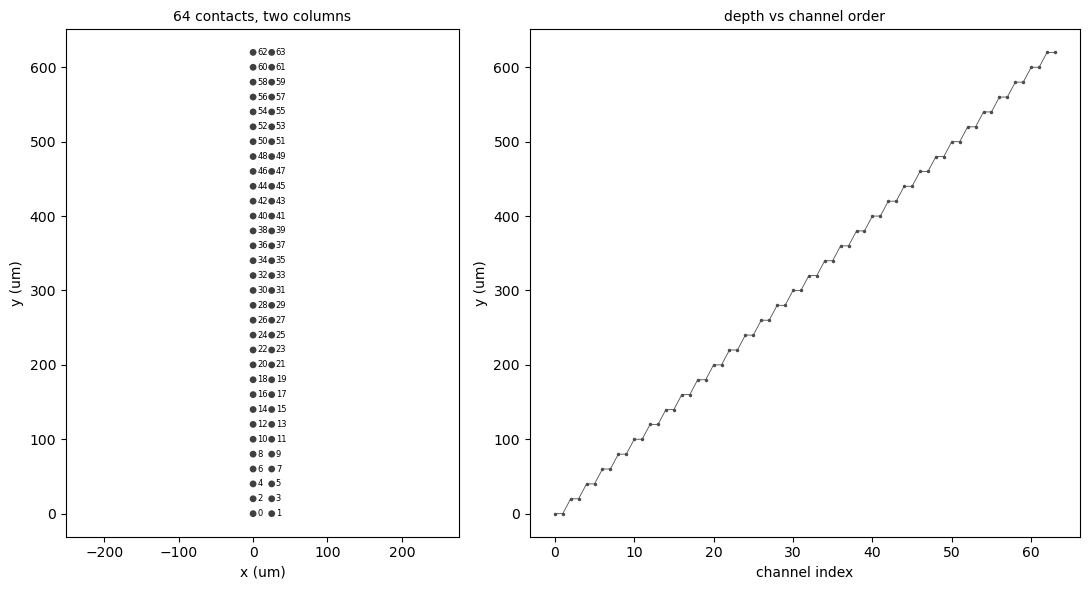

{'chanMap': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63]),
 'xc': array([ 0., 25.,  0., 25.,  0., 25.,  0., 25.,  0., 25.,  0., 25.,  0.,
        25.,  0., 25.,  0., 25.,  0., 25.,  0., 25.,  0., 25.,  0., 25.,
         0., 25.,  0., 25.,  0., 25.,  0., 25.,  0., 25.,  0., 25.,  0.,
        25.,  0., 25.,  0., 25.,  0., 25.,  0., 25.,  0., 25.,  0., 25.,
         0., 25.,  0., 25.,  0., 25.,  0., 25.,  0., 25.,  0., 25.]),
 'yc': array([  0.,   0.,  20.,  20.,  40.,  40.,  60.,  60.,  80.,  80., 100.,
        100., 120., 120., 140., 140., 160., 160., 180., 180., 200., 200.,
        220., 220., 240., 240., 260., 260., 280., 280., 300., 300., 320.,
        320., 340., 340., 360., 360., 380., 380., 400., 400., 420., 420.,
        440., 440., 460., 460

In [4]:
inspect(probe, title=f'{N_CONTACTS} contacts, two columns')

## 3. Save it

`configs/probes/` is where probe files live, and a session names one with
`probe_file:`. A relative path there resolves against the repo, so it works from
any working directory.

Give it a name that says *which array*, not which probe type -- the point of the
file is that a specific array in a specific monkey has a specific map.

In [5]:
NAME = "example_2col_64.json"     # e.g. utah_athos_A.json, np_athos_2026_08_13.json

# Written to a scratch path here so the example does not land in
# configs/probes/, which is for real array maps a session points at.
# Change PROBE_DIR to save one for real.
out = save_probe_json(probe, Path(tempfile.mkdtemp()) / NAME, indent=2)
print(f"wrote {out}")

# Round-trip it, to confirm what a session will actually load.
reloaded = load_probe_json(out)
print(f"reloaded: {reloaded['n_chan']} channels, {validate_probe(reloaded) or 'valid'}")

wrote /var/folders/9l/yg9chhr17tq5hfkjnskshf2c0000gr/T/tmp5l2ev7zd/example_2col_64.json
reloaded: 64 channels, valid


## Converting an existing map -- use the script

Anything that already exists in another format is a conversion, and
`tools/make_probe.py` does all of them. It runs the same validation, and `--plot`
draws the same picture:

```bash
# an older Kilosort .mat channel map
python tools/make_probe.py from-mat --mat <old>.mat \
       --out configs/probes/np1_default.json --plot

# a Neuropixels run, from its own ~snsGeomMap
python tools/make_probe.py neuropixels --meta <run>_t0.imec0.ap.meta \
       --out configs/probes/np_<session>.json --plot

# a Utah array, from the array's .cmp wiring map
python tools/make_probe.py utah --cmp array.cmp \
       --out configs/probes/utah_<array>.json --plot

# look at one you already have
python tools/make_probe.py show --probe configs/probes/utah_<array>.json --plot
```

**A real Neuropixels session usually needs none of this.** `setup_probe` reads
`~snsGeomMap` from the run's own `.meta`, which records which sites were actually
active for that recording -- leave `probe_file: null` and let it. Convert only when
there is no usable `.meta`.

## Using the probe file

Name it in the session config:

```yaml
neuropixels:
  probe_file: configs/probes/np_athos_2026_08_13.json
blackrock:
  probe_file: /path/to/array.cmp              # the array's own wiring
  # ...or, the same key, a map built from one:
  probe_file: configs/probes/utah_athos_A.json
  # The extension picks the reader: .cmp, .json or .mat.
```

What is in `configs/probes/` now:

In [6]:
saved = sorted(PROBE_DIR.glob("*.json"))
print(f"{len(saved)} probe file(s) in {PROBE_DIR}")
for path in saved:
    probe = load_probe_json(path)
    print(f"  {path.name}: {probe['n_chan']} channels, {validate_probe(probe) or 'valid'}")

1 probe file(s) in /Users/xuefeiyu/Documents/XuefeiFile/WorkRelated/Program_Python/SpikeSortingKilosort/configs/probes
  np1_default.json: 384 channels, valid
